In [1]:
import sys
import numpy as np
import pandas as pd
sys.path.append('../')

# Import the cntmosaic package
from cntmosaic.datasets import load_age_distribution, load_template_patterns
from cntmosaic.preprocess import make_full_grid
from cntmosaic.sim import ParticipantGenerator, ContactMatrixGenerator, ContactGenerator
from cntmosaic.vis import plot_mosaic, plot_mosaic_marginal, plot_mosaic_empirical

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

Use the `load_age_distribution` and `load_template_patterns` functions to load the population age distribution and template contact patterns for a given country.

In [2]:
df_age_dist = load_age_distribution('United_States')
patterns = load_template_patterns('United_States')

To generate participant data, use the `ParticipantGenerator` class. Pass the number of participants and the age distribution to the constructor. The `generate` method will return a data frame with the generated data.

In [3]:
pg = ParticipantGenerator(n=1000, age_dist=df_age_dist['P'].values)
df_part = pg.generate()

To generate a contact intensity matrix, use the `ContactyMatrixGenerator` class. Pass a dictionary of template patterns (can be obtained using the `load_template_patterns` function) and the age distribution. The `generate` method will return a numpy array of contact intensities.

In [4]:
cmg = ContactMatrixGenerator(patterns, df_age_dist['P'].values)
cint_matrix = cmg.generate()

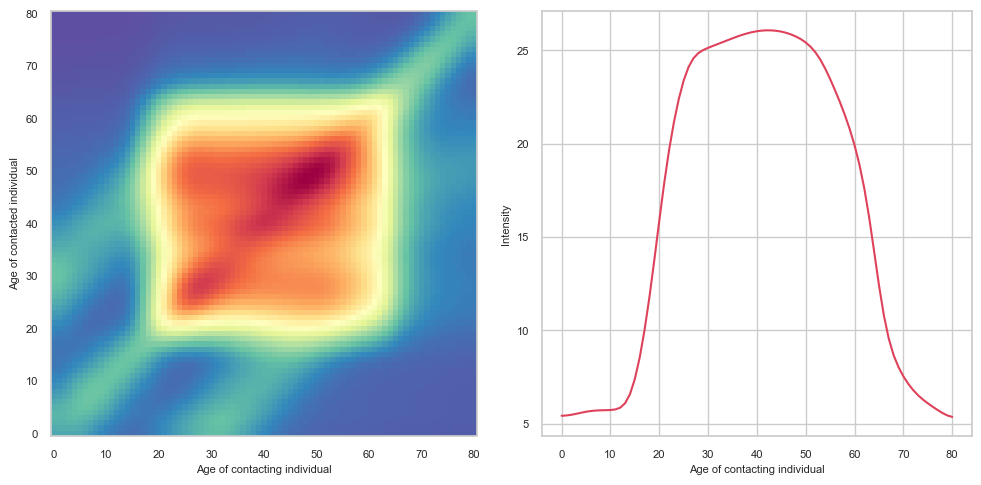

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
plot_mosaic(cint_matrix, ax[0])
plot_mosaic_marginal(cint_matrix.sum(axis=1), ax[1])
fig.tight_layout()

To generate contact data, use the `ContactGenerator` class. Pass the participant data generated by the `ParticipantGenerator` and the contact intensity matrix generated by the `ContactyMatrixGenerator`. The `generate` method will return a data frame with the generated contact data.

In [6]:
cg = ContactGenerator(df_part, cint_matrix)
df_cnt = cg.generate()

## Generate Contact Data for multiple subgroups

In [9]:
df_age_dist_us = load_age_distribution('United_States')
df_age_dist_uk = load_age_distribution('United-Kingdom')

patterns_us = load_template_patterns('United_States')
patterns_uk = load_template_patterns('United-Kingdom')

In [10]:
df_part = ParticipantGenerator(n=[1000, 2000], age_dist=[df_age_dist_us['P'].values, df_age_dist_uk['P'].values]).generate()

In [12]:
cmg_us = ContactMatrixGenerator(patterns_us, df_age_dist_us['P'].values)
cmg_uk = ContactMatrixGenerator(patterns_uk, df_age_dist_uk['P'].values)

cint_matrices = [cmg_us.generate(), cmg_uk.generate()]

In [15]:
df_cnt = ContactGenerator(df_part, cint_matrices).generate()